
# Superstore Sales — Data Visualization
## CodeAlpha Internship | Task 3

**This notebook presents a series of visualizations built on the Superstore**
**Sales Dataset to uncover key business insights using**
# Python, Pandas, Matplotlib, and Seaborn.



## Step 1

## Import libraries & Load data

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv(r"D:\python\EDA Code Alpha\Sample Superstore.csv", encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month


print(f"Shape of the dataset: {df.shape}")

Shape of the dataset: (9994, 23)


In [9]:
##df
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

## Step 2

## Sales by Category

**Which Category genertes the most revenue?**

C:\Users\m\AppData\Local\Temp\ipykernel_16420\922642793.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette='Blues_d')


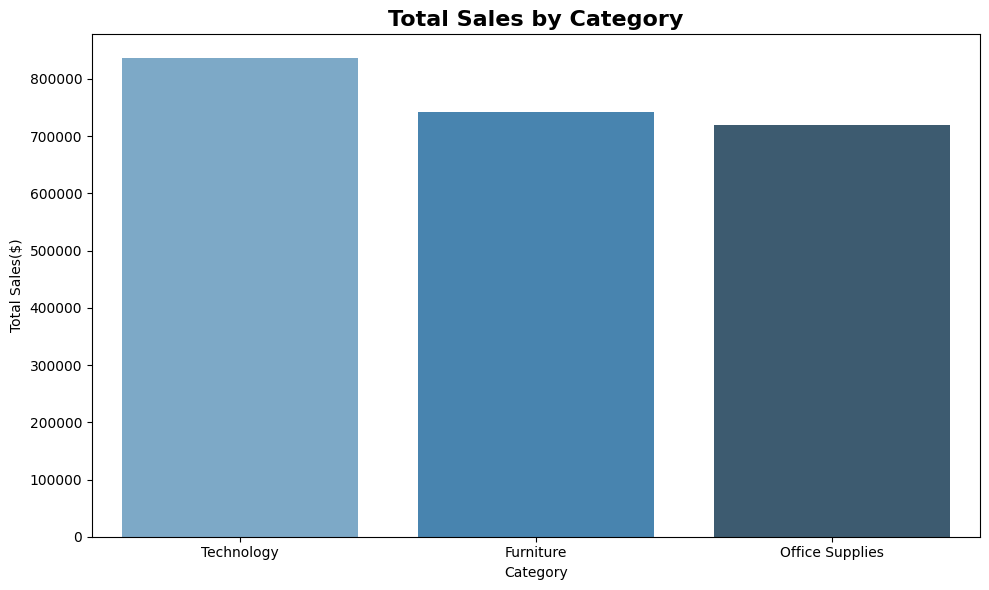

In [6]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=category_sales.index, y=category_sales.values, palette='Blues_d')
plt.title('Total Sales by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Sales($)')
plt.tight_layout()
plt.show()

## nsight:
Technology leads in total sales with **$836K**, 
followed by Furniture at **$742K** and Office Supplies at **$719K**.




## Step 3 — Profit by Category
High sales don't always mean high profit. Let's compare.


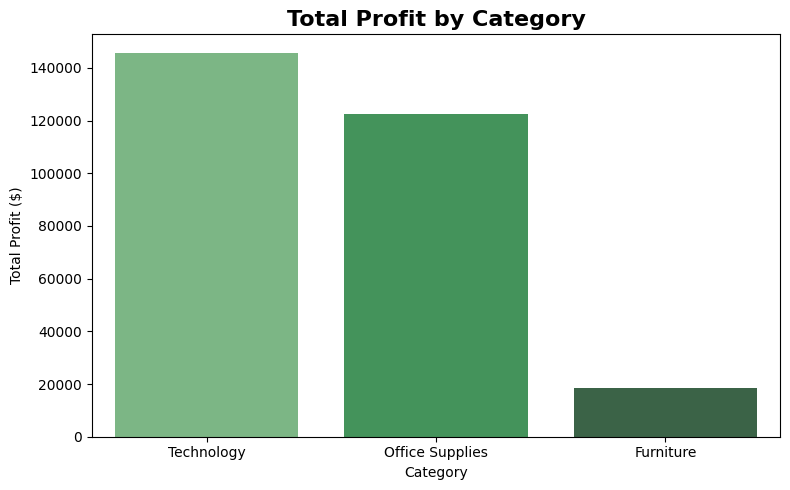

In [28]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_profit.index, y=category_profit.values, palette='Greens_d')
plt.title('Total Profit by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Profit ($)')
plt.tight_layout()
plt.show()

## Insight:
Despite being the second highest in sales, 
Furniture has the lowest profit at **$18K** only, 
due to high discount rates.



## Step 4 — Profit by Region

Which region is the most profitable?


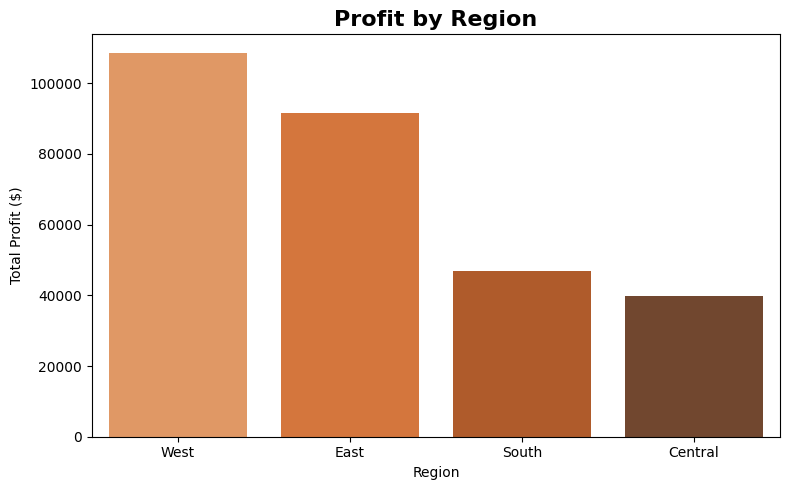

In [29]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=region_profit.index, y=region_profit.values, palette='Oranges_d')
plt.title('Profit by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Profit ($)')
plt.tight_layout()
plt.show()

## Insight:
West is the most profitable region with **$108K**, 
while Central is the weakest with only **$39K**.



## Step 5 — Monthly Sales Trend

How did sales grow over the years month by month?


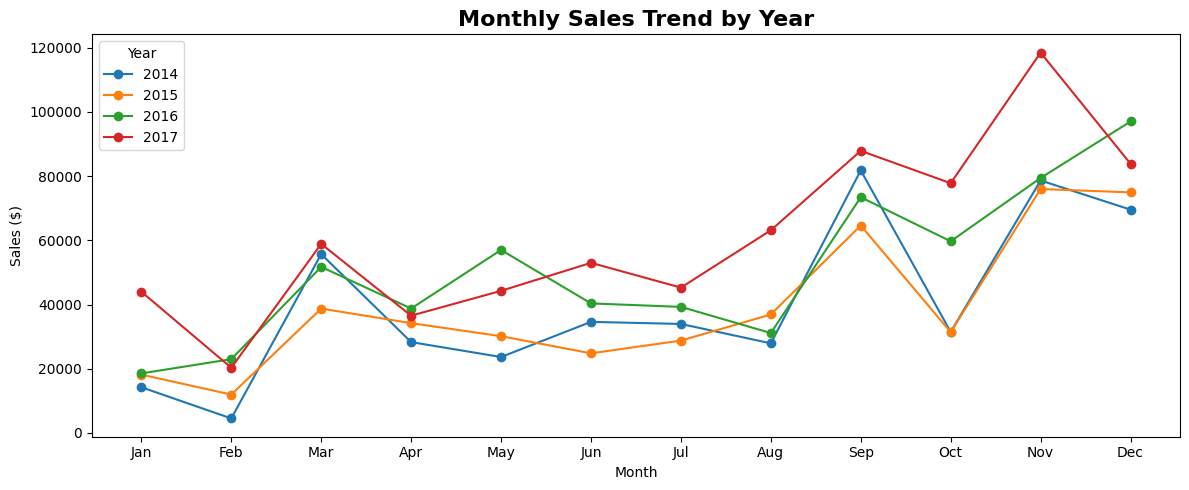

In [40]:

monthly = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

plt.figure(figsize=(12, 5))
for year in monthly['Year'].unique():
    data = monthly[monthly['Year'] == year]
    plt.plot(data['Month'], data['Sales'], marker='o', label=str(year), linewidth=1.5)

plt.title('Monthly Sales Trend by Year', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend(title='Year')
plt.tight_layout()
plt.show()

## Insight:
Sales show consistent yearly growth. 
November and December are peak months every year, 
while February records the lowest sales.



## Step 6 — Discount vs Profit

Does a higher discount lead to lower profit?

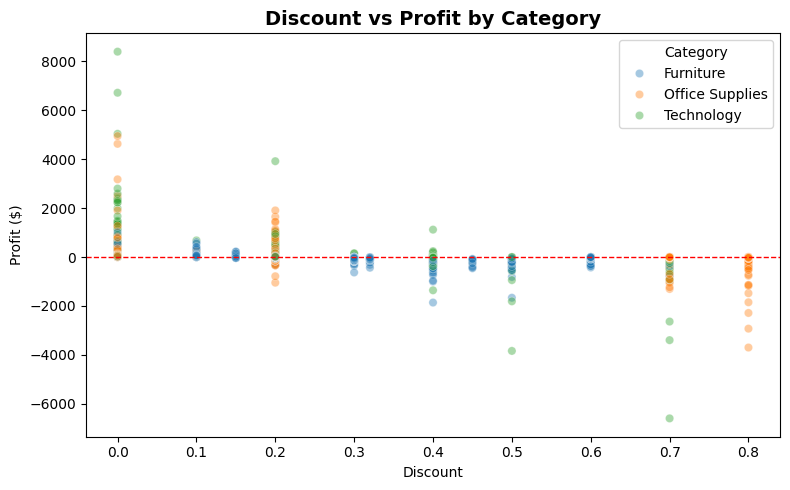

In [45]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Discount'], y=df['Profit'], 
                hue=df['Category'], alpha=0.4)
plt.title('Discount vs Profit by Category', fontsize=14, fontweight='bold')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.axhline(0, color='red', linewidth=1, linestyle='--')
plt.tight_layout()
plt.show()

## Insight:
Discounts above 40% consistently result in losses 
across all categories. Furniture is the most affected category.

## Step 7 — Top 10 Sub-Categories by Profit

Which sub-categories are the most and least profitable?

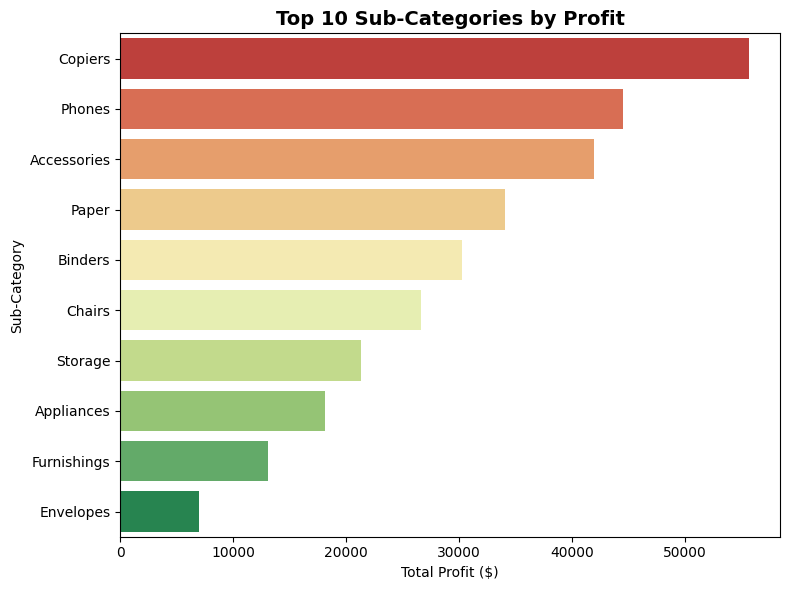

In [10]:
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(x=sub_profit.values, y=sub_profit.index, palette='RdYlGn')
plt.title('Top 10 Sub-Categories by Profit', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.ylabel('Sub-Category')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.show()

## Insight: 
**Copiers are the most profitable sub-category**, 
followed by Phones and Accessories. 
All top 10 sub-categories generate positive profit.

============================================= **insight**======================================================


## Key Insights — Data Visualization

### 1. Sales by Category
- Technology leads in total sales with $836K
- All three categories have relatively close sales figures

### 2. Profit by Category
- Technology is the most profitable with $145K
- Furniture has the lowest profit at $18K despite high sales

### 3. Profit by Region
- West is the most profitable region with $108K
- Central is the weakest region with only $39K

### 4. Monthly Sales Trend
- Sales grow consistently year over year
- November and December are peak months every year
- February records the lowest sales each year

### 5. Discount vs Profit
- Discounts above 40% consistently result in losses
- Furniture is the most affected category by high discounts

### 6. Top Sub-Categories
- Copiers are the most profitable sub-category
- Phones and Accessories follow in second and third place
